In [1]:
# Initialisers
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display
sp.init_printing(use_latex=True)

# Adjoint
def dagger(A):
    return A.conjugate().T

# Kronecker tensor product
def kron(A, B):
    return sp.kronecker_product(A, B)

# Rotation matrix
def rotation(theta):
    return sp.Matrix([[sp.cos(theta), -sp.sin(theta)],
                    [sp.sin(theta),  sp.cos(theta)]])

# Changeable list of theta values
theta_vals = [-sp.pi/4, 0, sp.pi/8, sp.pi/6, sp.pi/4, sp.pi/2, sp.pi]


**1. Calculating p(t) for a certain target node after t steps, starting at some initial position.**

In [2]:
# Choose values for the target node, initial position, and the number of time steps
target = int(input("Enter target node: "))
init_pos = int(input("Enter initial position: "))
t = int(input("Enter number of time steps: "))

L = 100
Npos = 2 * L + 1 # Positions -L to L
Ncoin = 2 # Dimension 2-D
dim = Npos * Ncoin

# Map positions to indices
def pos_index(i):
    return i + L

# Shift operator
S = sp.zeros(dim, dim)
for i in range(-L, L + 1):
    if i + 1 <= L:
        S[2 * pos_index(i + 1), 2 * pos_index(i)] = 1 # Move right
    if i - 1 >= -L:
        S[2 * pos_index(i - 1) + 1, 2 * pos_index(i) + 1] = 1 # Move left

# Projection operators
P_pos = sp.zeros(Npos, Npos)
P_pos[pos_index(target), pos_index(target)] = 1
I_coin = sp.eye(2)
P = kron(P_pos, I_coin)
Q = sp.eye(dim) - P

# Initial position
rho_pos = sp.zeros(Npos, Npos)
rho_pos[pos_index(init_pos), pos_index(init_pos)] = 1
rho_coin = sp.Rational(1, 2) * sp.Matrix([[1, 1],
                                        [1, 1]]) # Changeable spin state
rho0 = kron(rho_pos, rho_coin)

# Calculate p(t)
results = []

for theta in theta_vals:
    R = rotation(theta)
    U = S * kron(sp.eye(Npos), R)  # Unitary

    if init_pos == target:
                if t == 0:
                    p_t = 1.0
                else:
                    p_t = 0.0 # Set value for p(0) depending on target

    else:
        QU = Q * U
        A = P * U * (QU ** (t - 1))
        B = dagger(A)
        p_t = sp.trace(A * rho0 * B) # p(t) otherwise

    results.append((theta, float(p_t)))

# Print table of results for each value of theta
print("\nθ (rad)        p(t)")
print("---------------------------")
for theta, p in results:
    print(f"{float(theta):5.4f}    {p:1.5f}")



Enter target node: 1
Enter initial position: 0
Enter number of time steps: 1

θ (rad)        p(t)
---------------------------
-0.7854    1.00000
0.0000    0.50000
0.3927    0.14645
0.5236    0.06699
0.7854    0.00000
1.5708    0.50000
3.1416    0.50000


**2. Plot a graph of p(t) vs. t for the previous initial node and target node for a specified number of time steps.**

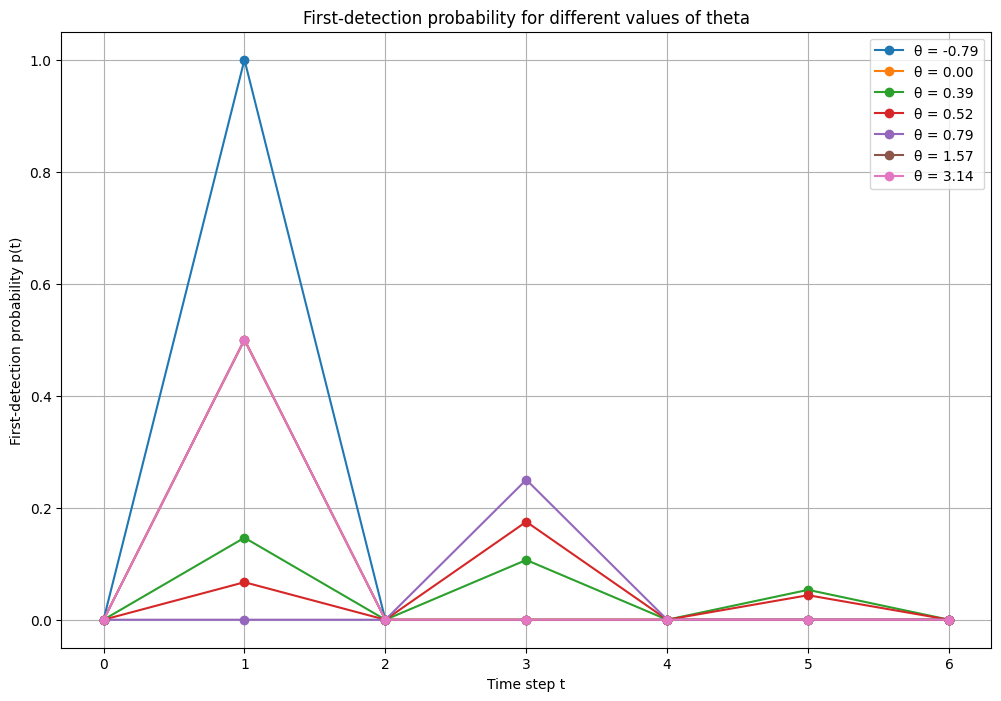

In [3]:
times = range(0, 7) # Time range

plt.figure(figsize=(12, 8))

# Calculate p(t) as previous
for theta in theta_vals:

    R = rotation(theta)
    U = S * kron(sp.eye(Npos), R)
    p_vals = []
    for t in times:

        if init_pos == target:
            p_t = 1.0 if t == 0 else 0.0

        elif t == 0:
            p_t = 0.0

        elif t == 1:
            A = P * U
            B = dagger(A)
            p_t = sp.trace(A * rho0 * B)

        else:
            QU = Q * U
            A = P * U * (QU ** (t - 1))
            B = dagger(A)
            p_t = sp.trace(A * rho0 * B)

        p_vals.append(float(p_t))

# Plot p(t) vs. t
    plt.plot(list(times), p_vals, marker='o', label=f"θ = {float(theta):.2f}")

plt.xlabel("Time step t")
plt.ylabel("First-detection probability p(t)")
plt.title("First-detection probability for different values of theta")
plt.legend()
plt.grid()
plt.show()